# 01 · Customer Churn & Retention

**Decision:** prioritize retention outreach while balancing the cost of unnecessary contacts against the cost of missed churners.

**Success criteria:** rank customers better than chance on a holdout set, compare against a simple logistic baseline, and make the operating-threshold trade-off visible.


## 1. Scope and data limitation

The 5,000 rows are generated with a fixed seed. This makes the workflow reproducible, but it also means the findings describe a simulated scenario—not a real telecom market. The model is a demonstration of analysis and decision design, not a production churn system.


In [1]:
from pathlib import Path
import subprocess, sys

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != '01-customer-churn':
    PROJECT_DIR = (PROJECT_DIR / '01-customer-churn').resolve()
REPO_ROOT = PROJECT_DIR.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
DATA_PATH = PROJECT_DIR / 'data' / 'churn.csv'
if not DATA_PATH.exists():
    subprocess.run([sys.executable, str(PROJECT_DIR / 'generate_data.py')], check=True)

df = pd.read_csv(DATA_PATH)
print(f'Rows: {len(df):,} | Columns: {df.shape[1]} | Churn rate: {df.Churn.mean():.1%}')
df.head()


Rows: 5,000 | Columns: 10 | Churn rate: 42.4%


,tenure,MonthlyCharges,Contract,InternetService,TechSupport,OnlineSecurity,PaymentMethod,SeniorCitizen,Dependents,Churn
0,7,23.39,One year,Fiber optic,Yes,No,Mailed check,1,0,0
1,56,88.30,One year,DSL,No,Yes,Electronic check,1,0,0
2,48,115.05,Month-to-month,DSL,Yes,Yes,Mailed check,1,0,1
3,32,102.92,Month-to-month,No,No,No,Bank transfer,1,0,1
4,32,47.72,One year,Fiber optic,Yes,Yes,Mailed check,0,0,0


## 2. Data-quality checks

Before modeling, check schema, missingness, duplicates, allowed target values, and plausible numeric ranges. These checks make silent data problems visible.


In [2]:
quality = {
    'duplicate_rows': int(df.duplicated().sum()),
    'missing_cells': int(df.isna().sum().sum()),
    'target_values': sorted(df['Churn'].unique().tolist()),
    'tenure_range': (int(df['tenure'].min()), int(df['tenure'].max())),
    'charge_range': (float(df['MonthlyCharges'].min()), float(df['MonthlyCharges'].max())),
}
quality


{'duplicate_rows': 0,
 'missing_cells': 0,
 'target_values': [0, 1],
 'tenure_range': (1, 72),
 'charge_range': (20.03, 120.0)}

## 3. Exploratory analysis

The charts describe association only. Contract and tenure can help prioritize outreach, but they do not prove which intervention will prevent churn.


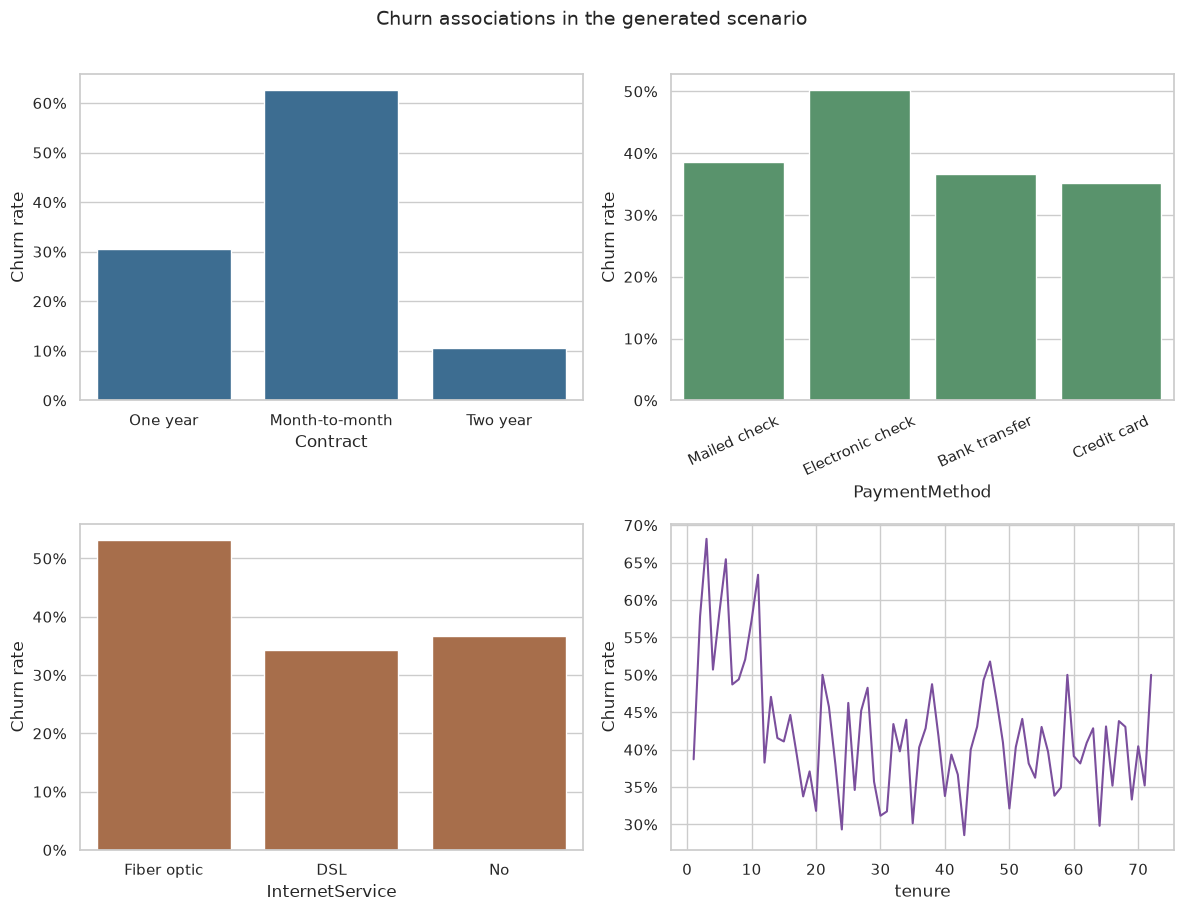

In [3]:
ASSETS = PROJECT_DIR / 'assets'
ASSETS.mkdir(exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
sns.barplot(data=df, x='Contract', y='Churn', errorbar=None, ax=axes[0, 0], color='#2f6f9f')
sns.barplot(data=df, x='PaymentMethod', y='Churn', errorbar=None, ax=axes[0, 1], color='#4f9d69')
axes[0, 1].tick_params(axis='x', rotation=25)
sns.barplot(data=df, x='InternetService', y='Churn', errorbar=None, ax=axes[1, 0], color='#b66a3c')
sns.lineplot(data=df, x='tenure', y='Churn', errorbar=None, ax=axes[1, 1], color='#7b4f9d')
for ax in axes.flat:
    ax.set_ylabel('Churn rate')
    ax.yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
fig.suptitle('Churn associations in the generated scenario', y=1.01, fontsize=14)
fig.tight_layout()
fig.savefig(ASSETS / 'eda.png', dpi=160, bbox_inches='tight')
plt.show()


## 4. Baseline and candidate model

A stratified holdout protects the evaluation from training-set optimism. Logistic regression is the interpretable baseline; a class-weighted random forest is the nonlinear candidate. ROC–AUC measures ranking quality independently of one threshold.


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

TARGET = 'Churn'
NUMERIC = ['tenure', 'MonthlyCharges', 'SeniorCitizen', 'Dependents']
CATEGORICAL = ['Contract', 'InternetService', 'TechSupport', 'OnlineSecurity', 'PaymentMethod']
FEATURES = NUMERIC + CATEGORICAL

x_train, x_test, y_train, y_test = train_test_split(
    df[FEATURES], df[TARGET], test_size=0.20, random_state=42, stratify=df[TARGET]
)

preprocessor = ColumnTransformer([
    ('numeric', StandardScaler(), NUMERIC),
    ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
])
models = {
    'Logistic baseline': LogisticRegression(max_iter=1_000, class_weight='balanced', random_state=42),
    'Random forest': RandomForestClassifier(
        n_estimators=250, min_samples_leaf=4, class_weight='balanced', random_state=42, n_jobs=-1
    ),
}

fitted = {}
rows = []
for name, estimator in models.items():
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', estimator)])
    pipeline.fit(x_train, y_train)
    probability = pipeline.predict_proba(x_test)[:, 1]
    fitted[name] = (pipeline, probability)
    rows.append({'model': name, 'holdout_roc_auc': roc_auc_score(y_test, probability)})

comparison = pd.DataFrame(rows).sort_values('holdout_roc_auc', ascending=False)
comparison


,model,holdout_roc_auc
0,Logistic baseline,0.886117
1,Random forest,0.870807


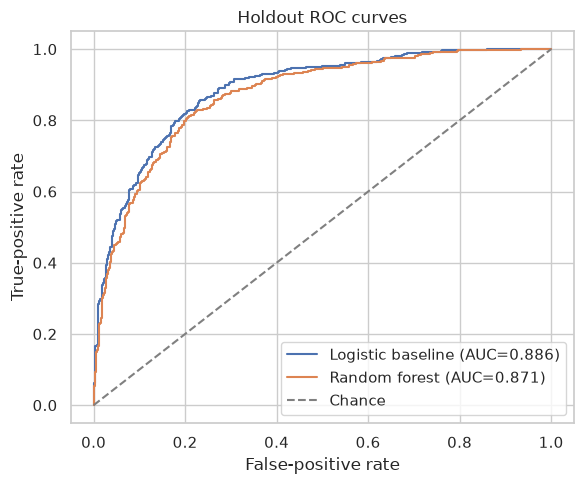

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, (_, probability) in fitted.items():
    fpr, tpr, _ = roc_curve(y_test, probability)
    auc = roc_auc_score(y_test, probability)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], '--', color='grey', label='Chance')
ax.set(xlabel='False-positive rate', ylabel='True-positive rate', title='Holdout ROC curves')
ax.legend()
fig.tight_layout()
fig.savefig(ASSETS / 'roc.png', dpi=160, bbox_inches='tight')
plt.show()


## 5. Threshold choice and workload

A model score becomes a business decision only after choosing a threshold. Lower thresholds capture more churners but also create more unnecessary contacts.


In [6]:
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

best_name = comparison.iloc[0]['model']
best_model, best_probability = fitted[best_name]
threshold_rows = []
for threshold in [0.30, 0.40, 0.50, 0.60, 0.70]:
    predicted = (best_probability >= threshold).astype(int)
    threshold_rows.append({
        'threshold': threshold,
        'precision': precision_score(y_test, predicted, zero_division=0),
        'recall': recall_score(y_test, predicted, zero_division=0),
        'f1': f1_score(y_test, predicted, zero_division=0),
        'customers_flagged': int(predicted.sum()),
    })
threshold_table = pd.DataFrame(threshold_rows)
threshold_table.style.format({'threshold': '{:.0%}', 'precision': '{:.1%}', 'recall': '{:.1%}', 'f1': '{:.3f}'})


,threshold,precision,recall,f1,customers_flagged
0,30%,63.1%,93.4%,0.753,628
1,40%,69.3%,90.3%,0.784,553
2,50%,74.1%,82.8%,0.782,474
3,60%,78.5%,73.3%,0.759,396
4,70%,84.8%,60.4%,0.705,302


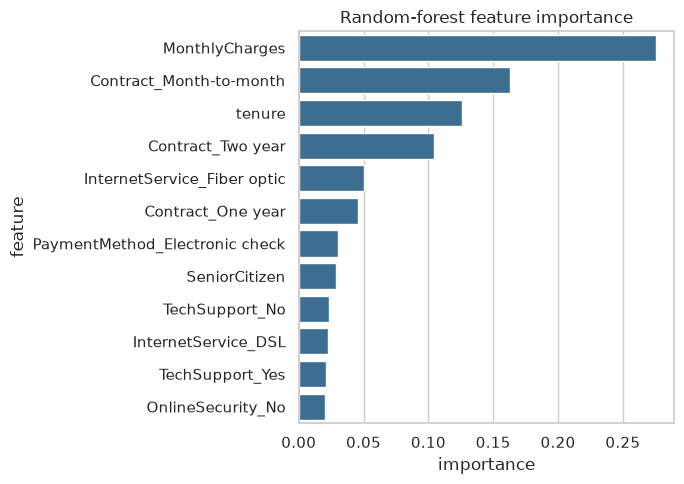

In [7]:
forest_model, _ = fitted['Random forest']
transformed_names = forest_model.named_steps['preprocessor'].get_feature_names_out()
importance = pd.DataFrame({
    'feature': [name.split('__', 1)[-1] for name in transformed_names],
    'importance': forest_model.named_steps['model'].feature_importances_,
}).sort_values('importance', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=importance, y='feature', x='importance', color='#2f6f9f', ax=ax)
ax.set_title('Random-forest feature importance')
fig.tight_layout()
fig.savefig(ASSETS / 'importance.png', dpi=160, bbox_inches='tight')
plt.show()


## 6. Controlled stakeholder brief

Only approved metrics and analyst-written context reach the text layer. If no token is configured, the output is a deterministic template.


In [8]:
from utils.ai_insights import generate_insights

selected = threshold_table.loc[threshold_table['threshold'].eq(0.50)].iloc[0]
best_auc = float(comparison.iloc[0]['holdout_roc_auc'])
brief = generate_insights({
    'headline': (
        f'{best_name} achieved holdout ROC–AUC {best_auc:.3f}. At a 0.50 threshold, '
        f'precision is {selected.precision:.1%}, recall is {selected.recall:.1%}, '
        f'and {int(selected.customers_flagged):,} of {len(y_test):,} holdout customers are flagged.'
    ),
    'drivers': ['Contract and billing profile', 'Early tenure', 'Service and support selections'],
    'recommendation': (
        'Use the score to prioritize a measured retention pilot. Select the threshold from '
        'contact capacity, customer value, and campaign cost; keep a randomized holdout.'
    ),
})
content = '# AI-assisted stakeholder brief — Customer Churn\n\n' + brief + '\n'
(PROJECT_DIR / 'insights.md').write_text(content, encoding='utf-8')
print(brief)


## What the data says
Logistic baseline achieved holdout ROC–AUC 0.886. At a 0.50 threshold, precision is 74.1%, recall is 82.8%, and 474 of 1,000 holdout customers are flagged.

## Factors to review
- Contract and billing profile
- Early tenure
- Service and support selections

## Recommended action
Use the score to prioritize a measured retention pilot. Select the threshold from contact capacity, customer value, and campaign cost; keep a randomized holdout.


## 7. Recommendation and limitations

- Pilot prioritized outreach instead of contacting everyone.
- Choose the operating threshold from campaign economics, not a default of 0.50.
- Measure incremental retention with a randomized holdout.
- Add customer value and intervention cost before production use.

**Main limitation:** the target was generated from known rules. A next version should use a documented real dataset, probability calibration, and out-of-time validation.
